In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = sns.load_dataset("titanic")

In [ ]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


**To check the null values**

In [ ]:
df1 = (df.isnull().sum() / len(df))*100
df1[df1>0]

,0
age,19.865320
embarked,0.224467
deck,77.216611
embark_town,0.224467


**drop the column where null values > 75%**

In [ ]:
df.drop("deck",axis="columns",inplace=True)

In [ ]:
df1 = (df.isnull().sum() / len(df))*100
df1[df1>0]

,0
age,19.865320
embarked,0.224467
embark_town,0.224467


**Null value Imputation**

In [ ]:
#categorical => median imputation
import numpy as np
a = [1,2,3,4,5,6,7,8,9,100]
np.array(a).mean()

np.float64(14.5)

In [ ]:
#1,2,3,4,5,6,7,8,9,100,null

#14.5 => mean
#5.5 => median

In [ ]:
df["age"].fillna(df["age"].median(),inplace=True)

In [ ]:
df1 = (df.isnull().sum() / len(df))*100
df1[df1>0]

,0
embarked,0.224467
embark_town,0.224467


In [ ]:
df["embarked"].mode()[0]

'S'

In [ ]:
#categorical = mode
#df["embarked"].mode()

df["embarked"].fillna(df["embarked"].mode()[0],inplace=True)
df["embark_town"].fillna(df["embark_town"].mode()[0],inplace=True)

/tmp/ipython-input-1400416121.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["embark_town"].fillna(df["embark_town"].mode()[0],inplace=True)


In [ ]:
df1 = (df.isnull().sum() / len(df))*100
df1[df1>0]

,0


**Define a function to clean the data**

In [ ]:
df = sns.load_dataset("titanic")


def data_clean(x):
  df1 = df.isnull().sum()
  for i in df1[df1>0].index:
    if df[i].isnull().sum()/len(df) > 0.75:
      df.drop(i,axis="columns",inplace=True)
    elif df[i].dtype == "int" or df[i].dtype == "float":
      df[i].fillna(df[i].median(),inplace=True)
    else:
      df[i].fillna(df[i].mode()[0],inplace=True)

In [ ]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [ ]:
data_clean(df)

/tmp/ipython-input-1898612128.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[i].fillna(df[i].median(),inplace=True)
/tmp/ipython-input-1898612128.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using '

In [ ]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


**Outlier Treatment**

{'whiskers': [<matplotlib.lines.Line2D at 0x7bf8945397c0>,
 'caps': [<matplotlib.lines.Line2D at 0x7bf894539d90>,
 'boxes': [<matplotlib.lines.Line2D at 0x7bf894757c50>],
 'medians': [<matplotlib.lines.Line2D at 0x7bf89453a3f0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7bf89453a6f0>],
 'means': []}

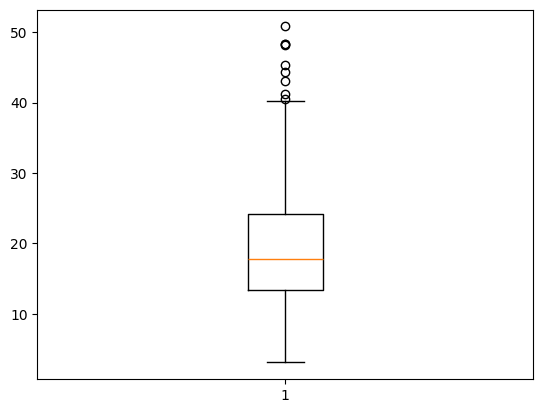

In [ ]:
df = sns.load_dataset("tips")
plt.boxplot(df["total_bill"])

**IQR - Inter Quartile Range**

In [ ]:
df["total_bill"].median()

17.795

In [ ]:
df["total_bill"].quantile(0.5)

#50th percentil // 2nd quarter

np.float64(17.795)

In [ ]:
df["total_bill"].quantile(0.25)

np.float64(13.3475)

In [ ]:
q1 = df["total_bill"].quantile(0.25)

q3 = df["total_bill"].quantile(0.75)

iqr = q3 - q1
print(iqr)

10.779999999999998


In [ ]:
ll = q1 - 1.5*iqr
ul = q3 + 1.5*iqr

In [ ]:
ll,ul

(np.float64(-2.8224999999999945), np.float64(40.29749999999999))

In [ ]:
df[(df["total_bill"]<ll) | (df["total_bill"] > ul)]

,total_bill,tip,sex,smoker,day,time,size
59,48.27,6.73,Male,No,Sat,Dinner,4
102,44.30,2.50,Female,Yes,Sat,Dinner,3
142,41.19,5.00,Male,No,Thur,Lunch,5
156,48.17,5.00,Male,No,Sun,Dinner,6
170,50.81,10.00,Male,Yes,Sat,Dinner,3
182,45.35,3.50,Male,Yes,Sun,Dinner,3
184,40.55,3.00,Male,Yes,Sun,Dinner,2
197,43.11,5.00,Female,Yes,Thur,Lunch,4
212,48.33,9.00,Male,No,Sat,Dinner,4


In [ ]:
df1 = df[(df["total_bill"]>ll) & (df["total_bill"] < ul)]

In [ ]:
len(df)

244

In [ ]:
len(df1)

235

{'whiskers': [<matplotlib.lines.Line2D at 0x7bf8945825d0>,
 'caps': [<matplotlib.lines.Line2D at 0x7bf894582d20>,
 'boxes': [<matplotlib.lines.Line2D at 0x7bf894582210>],
 'medians': [<matplotlib.lines.Line2D at 0x7bf8945835c0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7bf894583980>],
 'means': []}

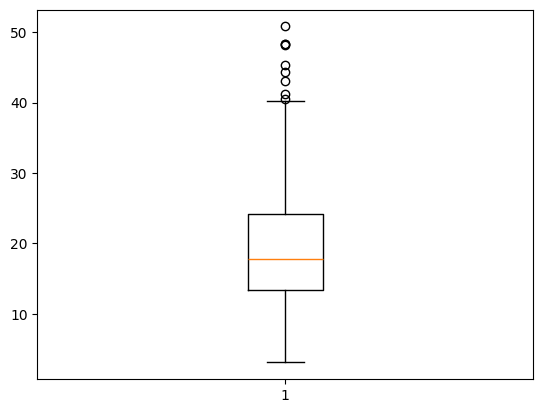

In [ ]:
plt.boxplot(df["total_bill"])

{'whiskers': [<matplotlib.lines.Line2D at 0x7bf8945bf200>,
 'caps': [<matplotlib.lines.Line2D at 0x7bf8945bf7d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7bf8945beed0>],
 'medians': [<matplotlib.lines.Line2D at 0x7bf8945bfc20>],
 'fliers': [<matplotlib.lines.Line2D at 0x7bf8945bff20>],
 'means': []}

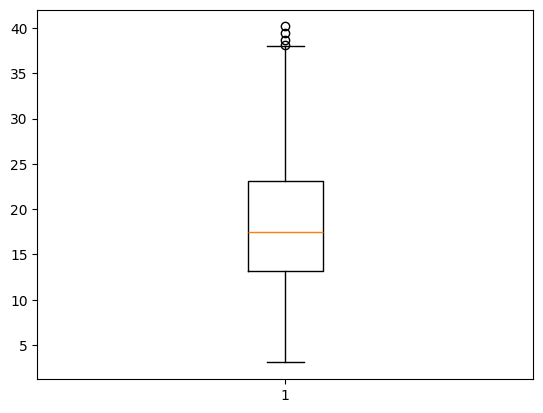

In [ ]:
plt.boxplot(df1["total_bill"])

**skewness**

/tmp/ipython-input-99596745.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(a)


<Axes: ylabel='Density'>

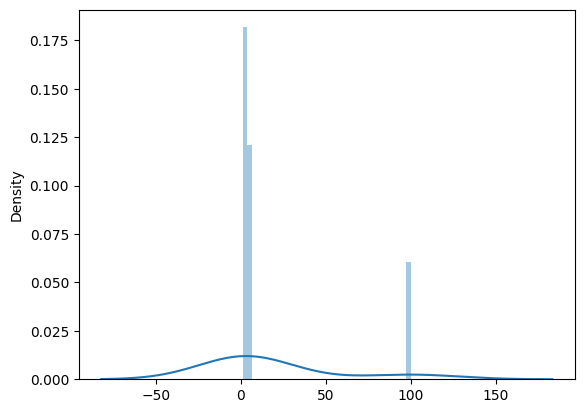

In [ ]:
#postive
#negative
a = [1,2,3,4,5,100]
pd.Series(a).skew()
sns.distplot(a)

/tmp/ipython-input-4087295146.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(a)


<Axes: ylabel='Density'>

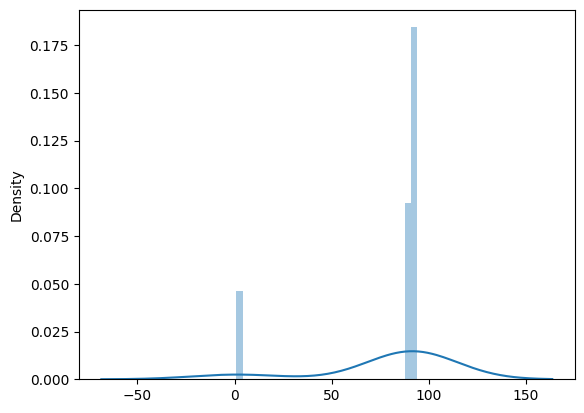

In [ ]:
a = [1,89,90,91,92,93,94]
pd.Series(a).skew()
sns.distplot(a)

In [ ]:
#skew > 0.5 => right skewed

#skew < -0.5 => left skewed

In [ ]:
df["total_bill"].skew()

np.float64(1.1332130376158205)

In [ ]:
df1["total_bill"].skew()

np.float64(0.7255976389840281)

In [ ]:
#height
#weight
#bmi

#year_built
#year - 2014
#year - 2018

#age - 2026 - 2014 => 12
df.dtypes

,0
total_bill,float64
tip,float64
sex,category
smoker,category
day,category
time,category
size,int64


**Label Encoder**

In [ ]:
#df[""].astype("")
#pd.to_datetime()

In [ ]:
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [ ]:
df["day"].unique()

['Sun', 'Sat', 'Thur', 'Fri']
Categories (4, object): ['Thur', 'Fri', 'Sat', 'Sun']

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["day_le"]=le.fit_transform(df["day"])

In [ ]:
df

,total_bill,tip,sex,smoker,day,time,size,day_le
0,16.99,1.01,Female,No,Sun,Dinner,2,2
1,10.34,1.66,Male,No,Sun,Dinner,3,2
2,21.01,3.50,Male,No,Sun,Dinner,3,2
3,23.68,3.31,Male,No,Sun,Dinner,2,2
4,24.59,3.61,Female,No,Sun,Dinner,4,2
...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,1
240,27.18,2.00,Female,Yes,Sat,Dinner,2,1
241,22.67,2.00,Male,Yes,Sat,Dinner,2,1
242,17.82,1.75,Male,No,Sat,Dinner,2,1


**Onehot encoding**

In [ ]:
pd.get_dummies(df[["day","sex","smoker","time"]],drop_first=True,dtype=int)

,day_Fri,day_Sat,day_Sun,sex_Female,smoker_No,time_Dinner
0,0,0,1,1,1,1
1,0,0,1,0,1,1
2,0,0,1,0,1,1
3,0,0,1,0,1,1
4,0,0,1,1,1,1
...,...,...,...,...,...,...
239,0,1,0,0,1,1
240,0,1,0,1,0,1
241,0,1,0,0,0,1
242,0,1,0,0,1,1


In [ ]:
pd.get_dummies(df["day"],drop_first=True,dtype=int)

,Fri,Sat,Sun
0,0,0,1
1,0,0,1
2,0,0,1
3,0,0,1
4,0,0,1
...,...,...,...
239,0,1,0
240,0,1,0
241,0,1,0
242,0,1,0


In [ ]:
df

,total_bill,tip,sex,smoker,day,time,size,day_le
0,16.99,1.01,Female,No,Sun,Dinner,2,2
1,10.34,1.66,Male,No,Sun,Dinner,3,2
2,21.01,3.50,Male,No,Sun,Dinner,3,2
3,23.68,3.31,Male,No,Sun,Dinner,2,2
4,24.59,3.61,Female,No,Sun,Dinner,4,2
...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,1
240,27.18,2.00,Female,Yes,Sat,Dinner,2,1
241,22.67,2.00,Male,Yes,Sat,Dinner,2,1
242,17.82,1.75,Male,No,Sat,Dinner,2,1


**Normalization (0 - 1)**

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit_transform(df[["total_bill"]])

#(x - x_min) / (x_max - x_min)

array([[0.29157939],
       [0.1522832 ],
       [0.3757855 ],
       [0.43171345],
       [0.45077503],
       [0.46543779],
       [0.11939673],
       [0.49874319],
       [0.25073314],
       [0.24528697],
       [0.15081693],
       [0.67427734],
       [0.25869292],
       [0.32174277],
       [0.24633431],
       [0.38772518],
       [0.15207373],
       [0.27691663],
       [0.29116045],
       [0.36824466],
       [0.31105991],
       [0.36070381],
       [0.2660243 ],
       [0.761416  ],
       [0.35085882],
       [0.30875576],
       [0.21575199],
       [0.20150817],
       [0.39023879],
       [0.34729786],
       [0.13573523],
       [0.32006703],
       [0.25115207],
       [0.36908253],
       [0.30812736],
       [0.43967323],
       [0.27733557],
       [0.29032258],
       [0.32718894],
       [0.59069962],
       [0.27167993],
       [0.30142438],
       [0.22769166],
       [0.13845832],
       [0.57247591],
       [0.31881022],
       [0.40134059],
       [0.614

**Standardization**

In [ ]:
df = sns.load_dataset("tips")
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit_transform(df[["total_bill"]])


array([[-3.14711305e-01],
       [-1.06323531e+00],
       [ 1.37779900e-01],
       [ 4.38315103e-01],
       [ 5.40744704e-01],
       [ 6.19536705e-01],
       [-1.23995452e+00],
       [ 7.98507107e-01],
       [-5.34203307e-01],
       [-5.63468908e-01],
       [-1.07111451e+00],
       [ 1.74175992e+00],
       [-4.91430507e-01],
       [-1.52624903e-01],
       [-5.57840908e-01],
       [ 2.01939101e-01],
       [-1.06436091e+00],
       [-3.93503306e-01],
       [-3.16962505e-01],
       [ 9.72582994e-02],
       [-2.10030504e-01],
       [ 5.67366990e-02],
       [-4.52034507e-01],
       [ 2.21000952e+00],
       [ 3.83349840e-03],
       [-2.22412104e-01],
       [-7.22178510e-01],
       [-7.98719310e-01],
       [ 2.15446301e-01],
       [-1.53017018e-02],
       [-1.15215771e+00],
       [-1.61629703e-01],
       [-5.31952107e-01],
       [ 1.01760699e-01],
       [-2.25788904e-01],
       [ 4.81087904e-01],
       [-3.91252106e-01],
       [-3.21464905e-01],
       [-1.2